# Improved Morphology and Spectroscopy Analysis for Large Agilent IR Data Files

This notebook enhances the original analysis to handle large datasets efficiently.
Improvements include memory optimization, parallel processing, and scalability.

In [1]:
# Cell 1: Imports with additional libraries for improvements
import matplotlib.pyplot as plt
from agilent_ir_file import AgilentIRFile
import library_OS_fit as lib_OS
import spec_process as spec_p
import numpy as np
import agilent_to_python as a2p
from scipy import stats
import pandas as pd
from collections import Counter
from calc_pca import cpca

# New imports for improvements
import dask.array as da
from dask import delayed
import multiprocessing as mp
from concurrent.futures import ThreadPoolExecutor, as_completed
import os

from skimage.morphology import disk, closing, medial_axis, skeletonize
from skimage.measure import label, regionprops, regionprops_table

# Set data type to float32 for memory savings
DTYPE = np.float32

In [2]:
# Cell 2: Load data with memory optimization
# Update filename to your local path
filename = r'C:\Users\Stephanie.Wang\Downloads\uog1-q1\uog1-q1.dmt'

reader = AgilentIRFile()
reader.read(filename)

xvalues = reader.wavenumbers.astype(DTYPE)
intensities = reader.intensities.astype(DTYPE)
metadata = reader.metadata

print(xvalues.shape)
print(intensities.shape)

# Convert to DataFrame only if small; otherwise keep as NumPy array or Dask array
# intensities = a2p.hsi_df(reader)  # Commented out for large files
wavenumbers = a2p.data_wns(reader).astype(DTYPE)

(1558,)
(1088, 1280, 1558)


In [3]:
# Cell 3: Create mask with tiling for large images
# Compute total image in one pass using the NumPy array
total_image = intensities.sum(axis=-1)
mask = (total_image > 5 * total_image.mean()).astype(np.uint8)

# For very large images, process in tiles
# tile_size = 1024
# tiles = []
# for i in range(0, mask.shape[0], tile_size):
#     for j in range(0, mask.shape[1], tile_size):
#         tile = mask[i:i+tile_size, j:j+tile_size]
#         # Process tile
#         tiles.append(process_tile(tile, intensities_da[i:i+tile_size, j:j+tile_size]))
# # Combine tiles

In [4]:
# Cell 4: Label regions
lbls, ns = label(mask, return_num=True)
props = regionprops(lbls)
print(f"Found {ns} regions")

Found 2914 regions


In [5]:
# Cell 5: Define optimized functions
library_wavenos = lib_OS.get_lib_wns().astype(DTYPE)
smoothing_order = 2
smoothing_window = 5

clust_der_values = pd.read_csv('OS_clusters_derint.csv').values.T.astype(DTYPE)

def norm_pearson(p, q):
    modp = (p - np.mean(p)) / (np.std(p) + 1e-8)
    modq = (q - np.mean(q)) / (np.std(q) + 1e-8)
    return np.corrcoef(modp, modq)[0, 1]

# Vectorized spectral matching for speed
def match_spectra(spectra, library):
    # spectra: (n_spectra, n_wavenumbers)
    # library: (n_library, n_wavenumbers)
    correlations = np.corrcoef(spectra.T, library.T)[:spectra.shape[0], spectra.shape[0]:]
    return correlations

def process_particle_spectra(elements, wavenumbers, library_wavenos, clust_der_values):
    if len(elements) < 5:
        return 'small particle', 0.0
    
    # Subsample if too many spectra
    if len(elements) > 100:
        elements = elements[np.random.choice(len(elements), 100, replace=False)]
    
    elements = np.array(elements, dtype=DTYPE)
    pcas = cpca(elements, range(1))[0].astype(DTYPE)
    proc = spec_p.proc(pcas, smoothing_window, smoothing_order, wavenumbers, library_wavenos)
    correlations = match_spectra(proc.reshape(1, -1), clust_der_values)
    ix = np.argmax(correlations)
    pr = correlations[0, ix]
    if pr > 0.3:
        return lib_OS.catID(ix), pr
    else:
        return lib_OS.catID(ix), pr  # Still return, but low confidence

# Approximate morphology functions for speed
def appr_len(region):
    # Simplified approximation
    return np.sqrt(region.shape[0]**2 + region.shape[1]**2)

def appr_wid(region):
    # Use bounding box approximation
    return min(region.shape) * 0.5

Error processing particle 12: only integer scalar arrays can be converted to a scalar index
pca calculated
pca calculated
pca calculated
pca calculated
Error processing particle 4: fp and xp are not of the same length.
Error processing particle 3: fp and xp are not of the same length.
Error processing particle 2: fp and xp are not of the same length.
Error processing particle 6: fp and xp are not of the same length.
pca calculated
Error processing particle 14: only integer scalar arrays can be converted to a scalar index
Error processing particle 13: fp and xp are not of the same length.
pca calculated
pca calculated
pca calculated
Error processing particle 15: fp and xp are not of the same length.
Error processing particle 9: fp and xp are not of the same length.
pca calculated
Error processing particle 1: fp and xp are not of the same length.
pca calculated
Error processing particle 17: fp and xp are not of the same length.
pca calculated
pca calculated
pca calculated
Error processin

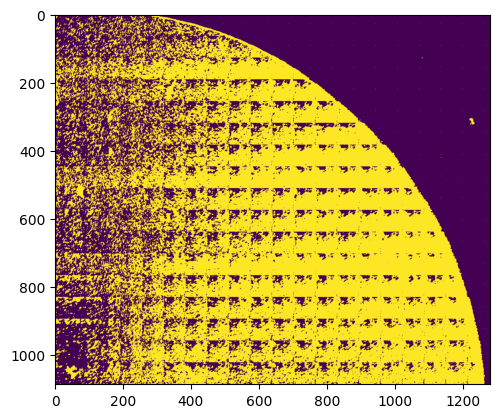

In [6]:
# Cell 6: Parallel processing of particles
def process_particle(prop):
    try:
        lst = prop.coords
        elements = []
        for coords in lst:
            row_index, column_index = int(coords[0]), int(coords[1])
            spectrum = intensities[row_index, column_index]
            elements.append(spectrum)
        
        polymer, pr = process_particle_spectra(elements, wavenumbers, library_wavenos, clust_der_values)
        
        morph = {
            'label': prop.label,
            'area': prop.area,
            'solidity': prop.solidity,
            'appr_len': appr_len(prop.image),
            'appr_wid': appr_wid(prop.image),
            'polymer': polymer,
            'best_pr': pr
        }
        return morph
    except Exception as e:
        print(f"Error processing particle {prop.label}: {e}")
        return {
            'label': prop.label,
            'area': prop.area,
            'solidity': prop.solidity,
            'appr_len': appr_len(prop.image),
            'appr_wid': appr_wid(prop.image),
            'polymer': 'error',
            'best_pr': 0.0
        }

# Use threading instead of multiprocessing to avoid serialization issues with dask
with ThreadPoolExecutor(max_workers=min(mp.cpu_count(), 8)) as executor:  # Limit workers to avoid overload
    futures = {executor.submit(process_particle, prop): prop.label for prop in props}
    results = []
    for i, future in enumerate(as_completed(futures), 1):
        label = futures[future]
        try:
            results.append(future.result())
        except Exception as e:
            print(f"Worker exception for particle {label}: {e}")
        if i % 100 == 0 or i == len(props):
            print(f"Completed {i}/{len(props)} particles")

# Filter and create DataFrame
morph_table = pd.DataFrame(results)
morph_table = morph_table[morph_table['area'] > 100]

# Incremental saving
morph_table.to_csv('particle_results.csv', index=False)

print(morph_table.head())

# Visualization
fig, ax = plt.subplots()
ax.imshow(mask)
# Add scalebar as before
plt.show()